In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from scipy.interpolate import interp1d

In [9]:
## -- load fitted LD coefficients
s3_wavesR100, s3_wavehwsR100, s3_u1, s3_u1err, s3_u2, s3_u2err = np.loadtxt("./data/spectra/V1298Tauc_SOSS_LCtest3_quadLD_LDcoefficients_R100.txt", skiprows=1, unpack=True)


## QUADRATIC
## ATLAS, via ExoCTK 
# 0 = wavelength, 1 = u1, 2 = u1 uncertainty, 3 = u2, 4 = u2 uncertainty
qldc_atlas = np.loadtxt('./data/limbdark/LDCs_V1298tau_quadratic_exoctkATLAS.csv', delimiter=' ', unpack=True, skiprows=21, usecols=[6, 8, 9, 10, 11])
a_qinterp1 = interp1d(x=qldc_atlas[0], y=qldc_atlas[1], bounds_error=None, fill_value='extrapolate')
a_qinterp2 = interp1d(x=qldc_atlas[0], y=qldc_atlas[3], bounds_error=None, fill_value='extrapolate')

a_qdu1 = a_qinterp1(s3_wavesR100)
a_qdu2 = a_qinterp2(s3_wavesR100)

## PHOENIX, via ExoCTK
# 0 = wavelength, 1 = u1, 2 = u1 uncertainty, 3 = u2, 4 = u2 uncertainty
qldc_phoenix = np.loadtxt('./data/limbdark/LDCs_V1298tau_quadratic_exoctkPHOENIX.csv', delimiter=' ', unpack=True, skiprows=21, usecols=[6, 8, 9, 10, 11])
p_qinterp1 = interp1d(x=qldc_phoenix[0], y=qldc_phoenix[1], bounds_error=None, fill_value='extrapolate')
p_qinterp2 = interp1d(x=qldc_phoenix[0], y=qldc_phoenix[3], bounds_error=None, fill_value='extrapolate')

p_qdu1 = p_qinterp1(s3_wavesR100)
p_qdu2 = p_qinterp2(s3_wavesR100)


In [10]:
c3 = '#6DADE2'

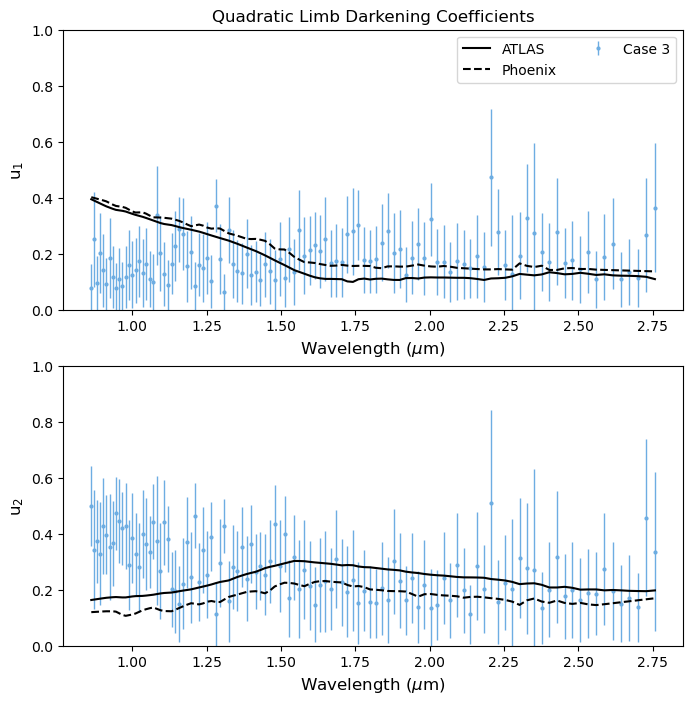

In [11]:
## -- quadratic:
fig, ax = plt.subplots(figsize=(8,8), nrows=2)
# top: u1
ax[0].set_title(r'Quadratic Limb Darkening Coefficients', fontsize=12)
ax[0].errorbar(s3_wavesR100, s3_u1, s3_u1err, c=c3, lw=1, ls='None', marker='o', ms=2, zorder=1, label='Case 3')
ax[0].plot(s3_wavesR100, a_qdu1, c='black', zorder=4, label='ATLAS')
ax[0].plot(s3_wavesR100, p_qdu1, c='black', ls='--', zorder=4, label='Phoenix')
ax[0].set_ylabel(r'u$_1$', fontsize=12)
ax[0].set_xlabel(r'Wavelength ($\mu$m)', fontsize=12)
ax[0].legend(loc='best', ncol=2)
ax[0].set_ylim(0,1)
# top: u2
ax[1].errorbar(s3_wavesR100, s3_u2, s3_u2err, c=c3, lw=1, ls='None', marker='o', ms=2, zorder=1, label='Case 3')
ax[1].plot(s3_wavesR100, a_qdu2, c='black', zorder=4, label='ATLAS')
ax[1].plot(s3_wavesR100, p_qdu2, c='black', ls='--', zorder=4, label='Phoenix')
ax[1].set_ylabel(r'u$_2$', fontsize=12)
ax[1].set_xlabel(r'Wavelength ($\mu$m)', fontsize=12)
ax[1].set_ylim(0,1)
plt.savefig('./figures/Figure12.png', dpi=600, bbox_inches='tight')
plt.savefig('./figures/Figure12.pdf', dpi=600, format='PDF', bbox_inches='tight')
plt.show()